**Task1:Data Cleaning And Formatting--**
>Remove/treat any special characters or non-numeric entries from financial fields.

In [3]:
import pandas as pd
import numpy as np
import re

# Load dataset
df = pd.read_csv("jp_morgan.csv")
# Preview first few rows
print(df.head())

   TransactionID CustomerID AccountID AccountType TransactionType  \
0              3   CUST2412  ACC80131        Loan      Withdrawal   
1             32   CUST1467  ACC74631     Current      Withdrawal   
2              9   CUST2699  ACC39482        Loan      Withdrawal   
3             42   CUST9535  ACC82947     Current      Withdrawal   
4            166   CUST7459  ACC39500      Credit         Payment   

         Product    Firm Region    Manager TransactionDate  TransactionAmount  \
0  Personal Loan  Firm C   West  Manager 3      06-08-2023        33759.69057   
1      Home Loan  Firm D  North  Manager 2      08-11-2023        69319.19933   
2    Credit Card  Firm D   West  Manager 4      15-05-2024        42831.48483   
3      Home Loan  Firm A  South  Manager 4      30-04-2023        70903.79697   
4      Home Loan  Firm D  South  Manager 4      16-02-2023        21948.97355   

   AccountBalance  RiskScore  CreditRating  TenureMonths  
0    126486.40830   0.225824           

In [4]:
financial_cols = ['TransactionAmount', 'AccountBalance']
for col in financial_cols:
    dirty_count = df[col].astype(str).str.contains(r'[^0-9.-]', regex=True, na=False).sum()
    print(f"{col}: {dirty_count} dirty values")

TransactionAmount: 0 dirty values
AccountBalance: 0 dirty values


In [5]:
def clean_financial(value):
    # Handle missing values
    if pd.isna(value):
        return np.nan
    
    # Convert to string
    value = str(value).strip()
    
    # Replace invalid text entries with NaN
    if value.lower() in ['n/a', 'null', 'unknown', 'none', '']:
        return np.nan
    
    # Remove all characters except digits, minus sign, and decimal point
    value = re.sub(r'[^0-9.-]', '', value)
    
    # Convert to numeric
    return float(value) if value not in ['', '-', '.'] else np.nan


In [6]:
financial_cols = ['TransactionAmount', 'AccountBalance']

for col in financial_cols:
    df[col] = df[col].apply(clean_financial)


print(df[financial_cols].head())
print(df[financial_cols].dtypes)

   TransactionAmount  AccountBalance
0        33759.69057    126486.40830
1        69319.19933     24834.76291
2        42831.48483    123007.43530
3        70903.79697     73073.64225
4        21948.97355    113405.32820
TransactionAmount    float64
AccountBalance       float64
dtype: object


In [7]:
print(df[financial_cols].isnull().sum())

TransactionAmount    0
AccountBalance       0
dtype: int64


**Convert currency amounts into numerical format.**

In [8]:
def convert_currency(value):
    # Handle missing values
    if pd.isna(value):
        return np.nan
    
    # Convert to string and remove extra spaces
    value = str(value).strip()
    
    # Handle invalid text values
    if value.lower() in ['n/a', 'null', 'unknown', 'none', '']:
        return np.nan
    
    # Remove currency symbols, commas, spaces, and special characters
    value = re.sub(r'[^0-9.-]', '', value)
    
    # Convert cleaned value to float
    return float(value) if value not in ['', '-', '.'] else np.nan


In [9]:
currency_cols = ['TransactionAmount', 'AccountBalance']

for col in currency_cols:
    df[col] = df[col].apply(convert_currency)

**Validate and format date columns.**

In [10]:
# Check raw date values
print(df['TransactionDate'].head())

0    06-08-2023
1    08-11-2023
2    15-05-2024
3    30-04-2023
4    16-02-2023
Name: TransactionDate, dtype: object


In [11]:
print(df['TransactionDate'].isna().sum())

0


In [12]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [13]:
df['TransactionDate'] = df['TransactionDate'].dt.strftime('%Y-%m-%d')

**Standardize Account Type**

In [14]:
print(df['AccountType'].unique())
print(df['TransactionType'].unique())

['Loan' 'Current' 'Credit' 'Savings']
['Withdrawal' 'Payment' 'Deposit' 'Transfer']


In [15]:
# Standardize categorical columns
df['AccountType'] = df['AccountType'].str.strip().str.title()
df['TransactionType'] = df['TransactionType'].str.strip().str.title()

# Verify
print(df['AccountType'].unique())
print(df['TransactionType'].unique())

['Loan' 'Current' 'Credit' 'Savings']
['Withdrawal' 'Payment' 'Deposit' 'Transfer']


**Task 2 Descriptive Transactional Analysis---**
>Calculate monthly and yearly summaries of total credits, debits, and net transaction 
volume.

In [16]:
import pandas as pd

# Convert date column
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

# Extract Year and Month
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month

# Classify credits and debits
df['Credit'] = df['TransactionAmount'].where(df['TransactionType'].isin(['Deposit', 'Transfer']), 0)
df['Debit'] = df['TransactionAmount'].where(df['TransactionType'].isin(['Withdrawal', 'Payment']), 0)

# Monthly Summary
monthly_summary = df.groupby(['Year', 'Month']).agg(
    Total_Credits=('Credit', 'sum'),
    Total_Debits=('Debit', 'sum')
).reset_index()

monthly_summary['Net_Transaction_Volume'] = monthly_summary['Total_Credits'] - monthly_summary['Total_Debits']

print("Monthly Transaction Summary")
print(monthly_summary)

# Yearly Summary
yearly_summary = df.groupby('Year').agg(
    Total_Credits=('Credit', 'sum'),
    Total_Debits=('Debit', 'sum')
).reset_index()

yearly_summary['Net_Transaction_Volume'] = yearly_summary['Total_Credits'] - yearly_summary['Total_Debits']

print("\nYearly Transaction Summary")
print(yearly_summary)

Monthly Transaction Summary
      Year  Month  Total_Credits  Total_Debits  Net_Transaction_Volume
0   2023.0    1.0   5.102059e+05  5.971297e+04           450492.934960
1   2023.0    2.0   1.483225e+05  4.550862e+04           102813.889060
2   2023.0    3.0   4.884382e+05  7.633500e+05          -274911.742999
3   2023.0    4.0   7.955520e+05  3.475854e+05           447966.609909
4   2023.0    5.0   2.939325e+05  3.322368e+05           -38304.275728
5   2023.0    6.0   1.254340e+06  1.149750e+06           104590.261819
6   2023.0    7.0   4.663289e+04  2.512888e+05          -204655.882200
7   2023.0    8.0   2.500422e+05  6.798389e+05          -429796.647961
8   2023.0    9.0   3.611348e+05  5.291440e+05          -168009.190450
9   2023.0   10.0   6.121150e+05  1.000634e+06          -388518.894401
10  2023.0   11.0   5.360043e+05  4.431379e+05            92866.433253
11  2023.0   12.0   2.221440e+05  1.928158e+05            29328.269624
12  2024.0    1.0   1.560952e+05  3.463299e+05   

**#Plot Trends**

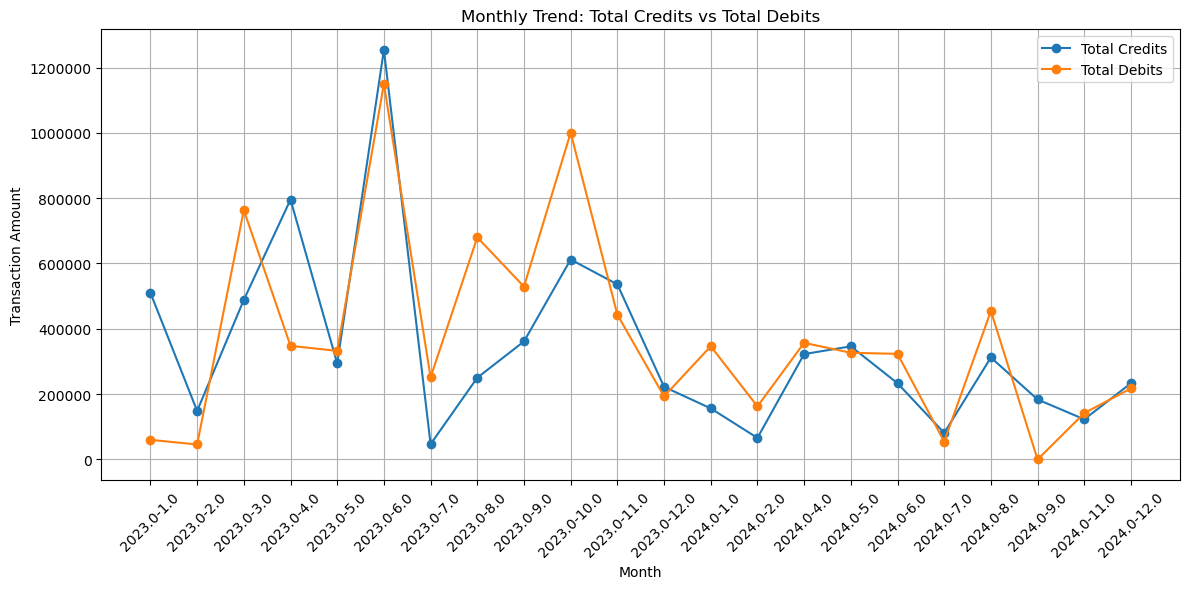

In [17]:
import matplotlib.pyplot as plt

monthly_summary['YearMonth'] = monthly_summary['Year'].astype(str) + '-' + monthly_summary['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12,6))

plt.plot(monthly_summary['YearMonth'], monthly_summary['Total_Credits'], marker='o', label='Total Credits')
plt.plot(monthly_summary['YearMonth'], monthly_summary['Total_Debits'], marker='o', label='Total Debits')

plt.title('Monthly Trend: Total Credits vs Total Debits')
plt.xlabel('Month')
plt.ylabel('Transaction Amount')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**#Identify top and bottom performing account**

In [18]:
# Account-wise performance
account_performance = df.groupby('AccountID').agg(
    Total_Credits=('Credit', 'sum'),
    Total_Debits=('Debit', 'sum')
).reset_index()

# Net inflow
account_performance['Net_Inflow'] = account_performance['Total_Credits'] - account_performance['Total_Debits']

# Top 10 accounts
top_accounts = account_performance.sort_values(by='Net_Inflow', ascending=False).head(10)

# Bottom 10 accounts
bottom_accounts = account_performance.sort_values(by='Net_Inflow', ascending=True).head(10)

print("Top Performing Accounts")
print(top_accounts)

print("\nBottom Performing Accounts")
print(bottom_accounts)

Top Performing Accounts
    AccountID  Total_Credits   Total_Debits     Net_Inflow
79   ACC42710  430507.297050  108987.579390  321519.717660
49   ACC29396  307426.228310       0.000000  307426.228310
8    ACC13357  303391.459070       0.000000  303391.459070
58   ACC32627  367732.189413  103735.834410  263996.355003
144  ACC75767  254145.448988       0.000000  254145.448988
188  ACC96868  236018.743680       0.000000  236018.743680
26   ACC22036  335813.468650  101812.702048  234000.766602
179  ACC92104  231854.015140       0.000000  231854.015140
109  ACC54589  225122.495180       0.000000  225122.495180
131  ACC67713  203189.357932       0.000000  203189.357932

Bottom Performing Accounts
    AccountID  Total_Credits   Total_Debits     Net_Inflow
193  ACC99549    2521.847520  337033.401670 -334511.554150
17   ACC18140   79940.845830  378278.364630 -298337.518800
66   ACC35419       0.000000  296560.677868 -296560.677868
50   ACC29477   81173.186940  361894.297917 -280721.110977
120 

**Identify and flag accounts as dormant or inactive if there is a gap of two months or more 
between consecutive transactions.**

In [19]:
# Sort by Account and Date
df = df.sort_values(by=['AccountID', 'TransactionDate'])

# Previous transaction date
df['Prev_TransactionDate'] = df.groupby('AccountID')['TransactionDate'].shift(1)

# Gap between transactions
df['Gap_Days'] = (df['TransactionDate'] - df['Prev_TransactionDate']).dt.days

# Flag dormant if gap >= 60 days
df['Dormant_Flag'] = df['Gap_Days'].apply(lambda x: 'Dormant' if x >= 60 else 'Active')

# Accounts with dormant activity
dormant_accounts = df[df['Dormant_Flag'] == 'Dormant']['AccountID'].unique()

print("Dormant / Inactive Accounts:")
print(dormant_accounts)

Dormant / Inactive Accounts:
['ACC10996' 'ACC11062' 'ACC11188' 'ACC11285' 'ACC12182' 'ACC15228'
 'ACC15359' 'ACC15925' 'ACC17688' 'ACC18057' 'ACC18140' 'ACC20297'
 'ACC21429' 'ACC22036' 'ACC22799' 'ACC23985' 'ACC24508' 'ACC25132'
 'ACC25811' 'ACC26940' 'ACC26956' 'ACC28295' 'ACC29007' 'ACC29231'
 'ACC29396' 'ACC29477' 'ACC29646' 'ACC30852' 'ACC32212' 'ACC32627'
 'ACC32890' 'ACC33287' 'ACC34119' 'ACC35419' 'ACC39544' 'ACC40939'
 'ACC40952' 'ACC42467' 'ACC42710' 'ACC43309' 'ACC45101' 'ACC49422'
 'ACC50439' 'ACC50817' 'ACC52131' 'ACC53466' 'ACC54589' 'ACC55331'
 'ACC57700' 'ACC60432' 'ACC61926' 'ACC62446' 'ACC64785' 'ACC65144'
 'ACC66086' 'ACC67713' 'ACC70741' 'ACC71426' 'ACC72197' 'ACC74631'
 'ACC75675' 'ACC77638' 'ACC78089' 'ACC78581' 'ACC81631' 'ACC82298'
 'ACC82926' 'ACC83269' 'ACC86784' 'ACC88074' 'ACC88252' 'ACC88286'
 'ACC88516' 'ACC89098' 'ACC92360' 'ACC92558' 'ACC94242' 'ACC95774'
 'ACC97225' 'ACC97411' 'ACC99549']


In [20]:
dormant_details = df[df['Dormant_Flag'] == 'Dormant'][
    ['AccountID', 'TransactionDate', 'Prev_TransactionDate', 'Gap_Days', 'Dormant_Flag']
]

print(dormant_details)

    AccountID TransactionDate Prev_TransactionDate  Gap_Days Dormant_Flag
141  ACC10996      2023-06-11           2023-01-07     155.0      Dormant
124  ACC11062      2024-08-01           2023-11-05     270.0      Dormant
373  ACC11188      2024-12-03           2023-07-03     519.0      Dormant
654  ACC11285      2024-08-06           2024-06-02      65.0      Dormant
286  ACC12182      2023-10-06           2023-04-08     181.0      Dormant
..        ...             ...                  ...       ...          ...
687  ACC97225      2024-01-01           2023-04-02     274.0      Dormant
467  ACC97225      2024-12-01           2024-01-01     335.0      Dormant
728  ACC97411      2023-08-11           2023-06-07      65.0      Dormant
288  ACC97411      2024-05-03           2023-08-11     266.0      Dormant
721  ACC99549      2024-06-04           2023-03-04     458.0      Dormant

[119 rows x 5 columns]


**Task 3 Customer Profile Building---**
>Group accounts by activity levels: High, Medium, Low based on transaction frequency on 
your analysis and rubrics. Do not forget to mention the rubric in the headings. 

In [21]:
# Count transactions per account
account_activity = df.groupby(['AccountID', 'CustomerID']).size().reset_index(name='Transaction_Count')

# Classification function
def classify_activity(count):
    if count > 1:
        return 'High Activity'
    elif count <= 1:
        return 'Medium Activity'
    else:
        return 'Low Activity'

# Apply activity classification
account_activity['Activity_Level'] = account_activity['Transaction_Count'].apply(classify_activity)

# Summary
activity_summary = account_activity['Activity_Level'].value_counts().reset_index()
activity_summary.columns = ['Activity_Level', 'Number_of_Accounts']

print("Customer Activity Profile")
print(activity_summary)

Customer Activity Profile
    Activity_Level  Number_of_Accounts
0  Medium Activity                 788
1    High Activity                   6


In [22]:
account_activity = df.groupby(['AccountID', 'CustomerID']).size().reset_index(name='Transaction_Count')

print(account_activity.head())

  AccountID CustomerID  Transaction_Count
0  ACC10117   CUST9525                  1
1  ACC10996   CUST1547                  1
2  ACC10996   CUST3725                  1
3  ACC10996   CUST4373                  1
4  ACC10996   CUST9843                  1


**Segment customers by average balance and transaction volume.**

In [23]:
# Build customer metrics
customer_profile = df.groupby('CustomerID').agg(
    Avg_Balance=('AccountBalance', 'mean'),
    Transaction_Count=('TransactionID', 'count'),
    Total_Transaction_Volume=('TransactionAmount', 'sum')
).reset_index()

# Balance segmentation
def classify_balance(balance):
    if balance > 100000:
        return 'High Balance'
    elif 50000 <= balance <= 100000:
        return 'Medium Balance'
    else:
        return 'Low Balance'

# Volume segmentation
def classify_volume(count):
    if count > 15:
        return 'High Volume'
    elif 8 <= count <= 15:
        return 'Medium Volume'
    else:
        return 'Low Volume'

# Apply segments
customer_profile['Balance_Segment'] = customer_profile['Avg_Balance'].apply(classify_balance)
customer_profile['Volume_Segment'] = customer_profile['Transaction_Count'].apply(classify_volume)

# Combined segment
customer_profile['Customer_Segment'] = customer_profile['Balance_Segment'] + ' | ' + customer_profile['Volume_Segment']

print(customer_profile.head())

  CustomerID   Avg_Balance  Transaction_Count  Total_Transaction_Volume  \
0   CUST1042  72029.783760                  3             239707.842520   
1   CUST1114  72200.316843                  4             148429.225518   
2   CUST1121  65967.294726                  5             234165.196290   
3   CUST1189  75396.365689                 10             355664.766380   
4   CUST1223  85890.369912                  9             553100.623290   

  Balance_Segment Volume_Segment                Customer_Segment  
0  Medium Balance     Low Volume     Medium Balance | Low Volume  
1  Medium Balance     Low Volume     Medium Balance | Low Volume  
2  Medium Balance     Low Volume     Medium Balance | Low Volume  
3  Medium Balance  Medium Volume  Medium Balance | Medium Volume  
4  Medium Balance  Medium Volume  Medium Balance | Medium Volume  


**Create profiles for: --**
>High-net inflow accounts,
High-frequency low-balance accounts,
Accounts with negative or near-zero balances

In [24]:
# Build account profile
account_profile = df.groupby(['AccountID', 'CustomerID']).agg(
    Total_Credits=('Credit', 'sum'),
    Total_Debits=('Debit', 'sum'),
    Transaction_Count=('TransactionID', 'count'),
    Avg_Balance=('AccountBalance', 'mean')
).reset_index()

# Net inflow
account_profile['Net_Inflow'] = account_profile['Total_Credits'] - account_profile['Total_Debits']

# 1. High-Net Inflow Accounts
high_net_inflow = account_profile[account_profile['Net_Inflow'] > 50000]

# 2. High-Frequency Low-Balance Accounts
high_freq_low_balance = account_profile[
    (account_profile['Transaction_Count'] > 15) &
    (account_profile['Avg_Balance'] < 50000)
]

# 3. Negative / Near-Zero Balance Accounts
negative_near_zero = account_profile[
    account_profile['Avg_Balance'] < 5000
]

print("High-Net Inflow Accounts")
print(high_net_inflow.head())

print("\nHigh-Frequency Low-Balance Accounts")
print(high_freq_low_balance.head())

print("\nNegative / Near-Zero Balance Accounts")
print(negative_near_zero.head())

High-Net Inflow Accounts
  AccountID CustomerID  Total_Credits  Total_Debits  Transaction_Count  \
0  ACC10117   CUST9525    56317.92006           0.0                  1   
1  ACC10996   CUST1547    92323.65567           0.0                  1   
3  ACC10996   CUST4373    81608.80093           0.0                  1   
5  ACC11062   CUST3778   103375.34420           0.0                  1   
8  ACC11062   CUST7098    61603.77231           0.0                  1   

   Avg_Balance    Net_Inflow  
0  90780.25664   56317.92006  
1  39827.55468   92323.65567  
3  67810.12401   81608.80093  
5  51672.12356  103375.34420  
8  76772.87576   61603.77231  

High-Frequency Low-Balance Accounts
Empty DataFrame
Columns: [AccountID, CustomerID, Total_Credits, Total_Debits, Transaction_Count, Avg_Balance, Net_Inflow]
Index: []

Negative / Near-Zero Balance Accounts
    AccountID CustomerID  Total_Credits  Total_Debits  Transaction_Count  \
45   ACC15671   CUST8091   46920.974500       0.00000       

**Task 4 Financial Risk Identification --->**
>Track accounts with frequent large withdrawals or overdrafts.

In [25]:
# 1. Frequent Large Withdrawals
large_withdrawals = df[
    (df['TransactionType'] == 'Withdrawal') &
    (df['TransactionAmount'] > 50000)
]

large_withdrawal_accounts = large_withdrawals.groupby(['AccountID', 'CustomerID']).size().reset_index(name='Large_Withdrawal_Count')

large_withdrawal_accounts = large_withdrawal_accounts[
    large_withdrawal_accounts['Large_Withdrawal_Count'] >= 2
]

# 2. Overdraft Risk Accounts
overdraft_accounts = df[df['AccountBalance'] < 0][
    ['AccountID', 'CustomerID', 'TransactionDate', 'AccountBalance']
]

# 3. Overdraft frequency
overdraft_frequency = df[df['AccountBalance'] < 0].groupby(
    ['AccountID', 'CustomerID']
).size().reset_index(name='Negative_Balance_Count')

print("Frequent Large Withdrawal Accounts")
print(large_withdrawal_accounts.head())

print("\nOverdraft Risk Accounts")
print(overdraft_accounts.head())

print("\nOverdraft Frequency")
print(overdraft_frequency.head())

Frequent Large Withdrawal Accounts
Empty DataFrame
Columns: [AccountID, CustomerID, Large_Withdrawal_Count]
Index: []

Overdraft Risk Accounts
    AccountID CustomerID TransactionDate  AccountBalance
568  ACC30852   CUST7395      2023-09-12   -13018.400900
756  ACC45907   CUST2915             NaT    -3430.668059
147  ACC49774   CUST6028             NaT     -584.724017
121  ACC50817   CUST9535             NaT   -13812.693060
102  ACC57516   CUST4769             NaT    -1308.418354

Overdraft Frequency
  AccountID CustomerID  Negative_Balance_Count
0  ACC30852   CUST7395                       1
1  ACC45907   CUST2915                       1
2  ACC49774   CUST6028                       1
3  ACC50817   CUST9535                       1
4  ACC57516   CUST4769                       1


**Calculate balance volatility using standard deviation or coefficient of variation.**

In [26]:
# Balance volatility metrics
balance_volatility = df.groupby(['AccountID', 'CustomerID']).agg(
    Avg_Balance=('AccountBalance', 'mean'),
    Balance_StdDev=('AccountBalance', 'std')
).reset_index()

# Coefficient of Variation
balance_volatility['Balance_CV'] = (
    balance_volatility['Balance_StdDev'] / balance_volatility['Avg_Balance']
)

# Handle infinite values
balance_volatility['Balance_CV'] = balance_volatility['Balance_CV'].replace(
    [float('inf'), -float('inf')], pd.NA
)

# Volatility classification
def classify_volatility(cv):
    if pd.isna(cv):
        return 'Undefined'
    elif cv > 0.7:
        return 'High Volatility'
    elif cv >= 0.3:
        return 'Moderate Volatility'
    else:
        return 'Low Volatility'

balance_volatility['Volatility_Level'] = balance_volatility['Balance_CV'].apply(classify_volatility)

print(balance_volatility.head())

  AccountID CustomerID   Avg_Balance  Balance_StdDev  Balance_CV  \
0  ACC10117   CUST9525   90780.25664             NaN         NaN   
1  ACC10996   CUST1547   39827.55468             NaN         NaN   
2  ACC10996   CUST3725  105586.14810             NaN         NaN   
3  ACC10996   CUST4373   67810.12401             NaN         NaN   
4  ACC10996   CUST9843   42962.44757             NaN         NaN   

  Volatility_Level  
0        Undefined  
1        Undefined  
2        Undefined  
3        Undefined  
4        Undefined  


**Use IQR or z-score methods to detect anomalies,Highlight customers with irregular or suspicious transaction behavior**

In [28]:
import numpy as np

# Calculate IQR for TransactionAmount
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag anomalies
df['IQR_Anomaly'] = df['TransactionAmount'].apply(
    lambda x: 'Anomaly' if (x < lower_bound or x > upper_bound) else 'Normal'
)

In [29]:
# Calculate mean and std
mean_amt = df['TransactionAmount'].mean()
std_amt = df['TransactionAmount'].std()

# Compute Z-score
df['Z_Score'] = (df['TransactionAmount'] - mean_amt) / std_amt

# Flag anomalies
df['Z_Anomaly'] = df['Z_Score'].apply(
    lambda x: 'Anomaly' if abs(x) > 3 else 'Normal'
)

df['Final_Anomaly_Flag'] = df.apply(
    lambda row: 'Anomaly' if (row['IQR_Anomaly'] == 'Anomaly' or row['Z_Anomaly'] == 'Anomaly')
    else 'Normal',
    axis=1
)

In [30]:
suspicious_customers = df[df['Final_Anomaly_Flag'] == 'Anomaly'] \
    .groupby('CustomerID') \
    .size() \
    .reset_index(name='Anomaly_Count')

# Sort by most suspicious
suspicious_customers = suspicious_customers.sort_values(by='Anomaly_Count', ascending=False)

print("Suspicious Customers")
print(suspicious_customers.head())

Suspicious Customers
  CustomerID  Anomaly_Count
0   CUST1189              1
1   CUST1497              1
2   CUST1644              1
3   CUST1747              1
4   CUST1749              1


In [31]:
anomaly_transactions = df[df['Final_Anomaly_Flag'] == 'Anomaly'][
    ['CustomerID', 'AccountID', 'TransactionAmount', 'TransactionType', 'TransactionDate', 'Z_Score']
]

print(anomaly_transactions.head())

    CustomerID AccountID  TransactionAmount TransactionType TransactionDate  \
97    CUST6391  ACC26940       -25964.94612         Payment             NaT   
129   CUST4373  ACC41829       135972.34390         Payment             NaT   
701   CUST6837  ACC46655       -29563.97803         Deposit             NaT   
53    CUST1189  ACC50439       -60979.07348         Deposit             NaT   
659   CUST1644  ACC77533       -30826.73980         Payment             NaT   

      Z_Score  
97  -2.649949  
129  2.919380  
701 -2.773727  
53  -3.854151  
659 -2.817156  


Visualisation **EDA**

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style='whitegrid')

# Optional: larger plots
plt.rcParams['figure.figsize'] = (10, 6)

**Distribution of transaction amount**

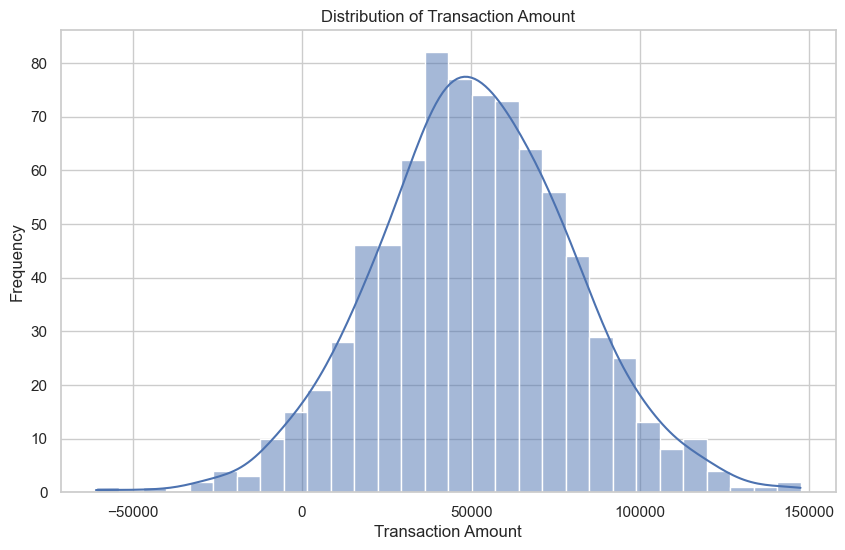

In [33]:
sns.histplot(df['TransactionAmount'], bins=30, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

**Transaction type distribution**

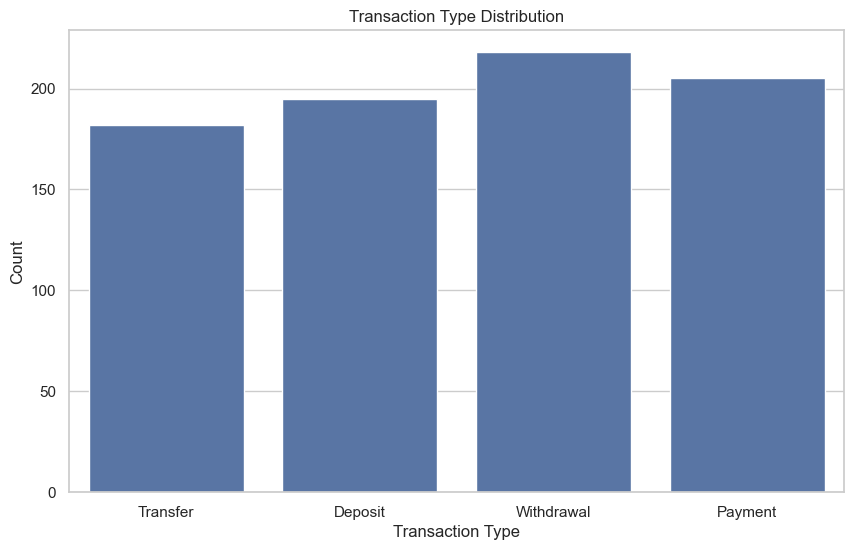

In [35]:
sns.countplot(x='TransactionType', data=df)
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

**Account type distribution**

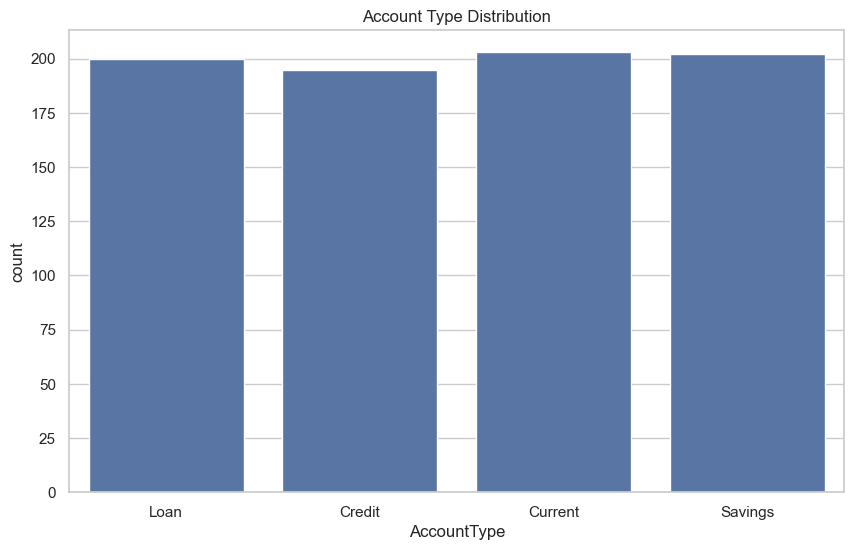

In [36]:
sns.countplot(x='AccountType', data=df)
plt.title('Account Type Distribution')
plt.show()

**Monthly transaction trend**

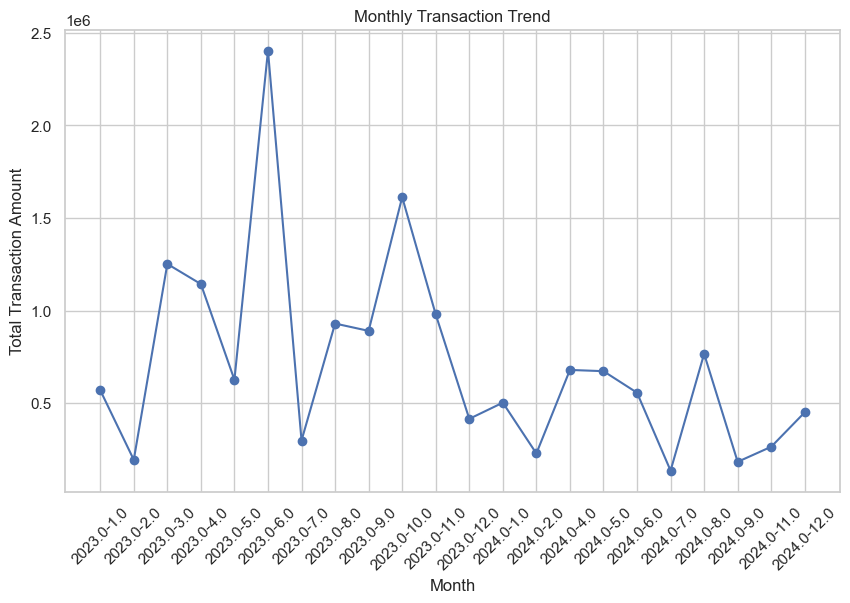

In [37]:
monthly_trend = df.groupby(['Year', 'Month'])['TransactionAmount'].sum().reset_index()

monthly_trend['YearMonth'] = monthly_trend['Year'].astype(str) + '-' + monthly_trend['Month'].astype(str)

plt.plot(monthly_trend['YearMonth'], monthly_trend['TransactionAmount'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Transaction Trend')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')
plt.show()

**Credit vs Debit trend**

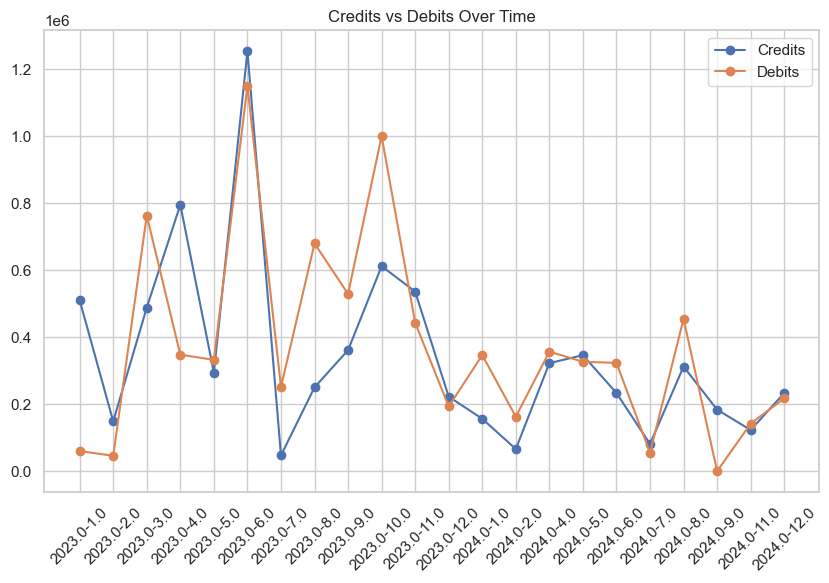

In [38]:
plt.plot(monthly_summary['YearMonth'], monthly_summary['Total_Credits'], label='Credits', marker='o')
plt.plot(monthly_summary['YearMonth'], monthly_summary['Total_Debits'], label='Debits', marker='o')

plt.legend()
plt.xticks(rotation=45)
plt.title('Credits vs Debits Over Time')
plt.show()

**Balance Distribution**

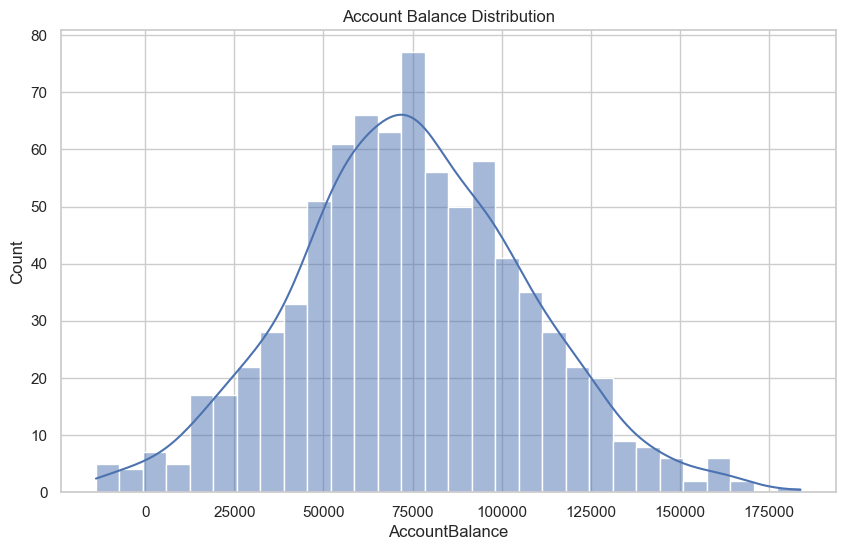

In [39]:
sns.histplot(df['AccountBalance'], bins=30, kde=True)
plt.title('Account Balance Distribution')
plt.show()

Balance vs Transaction

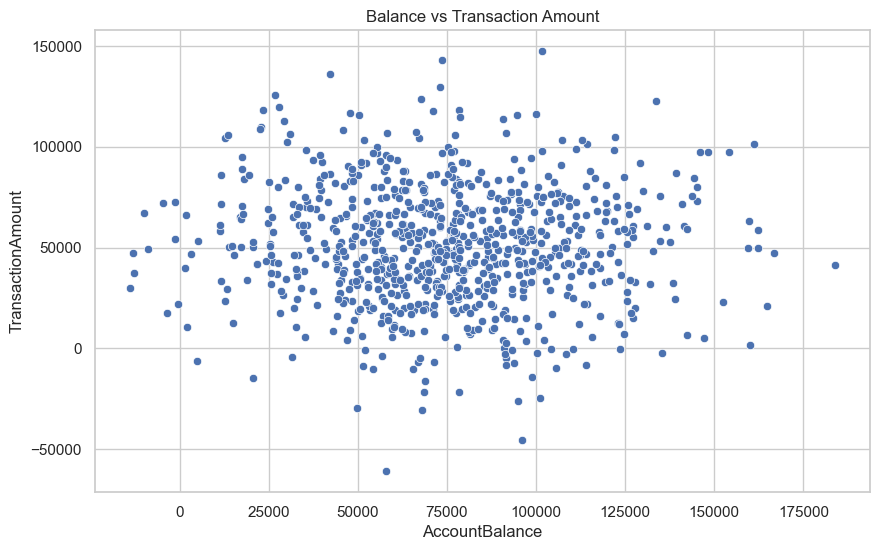

In [40]:
sns.scatterplot(x='AccountBalance', y='TransactionAmount', data=df)
plt.title('Balance vs Transaction Amount')
plt.show()

**Risk score vs Credit rating**

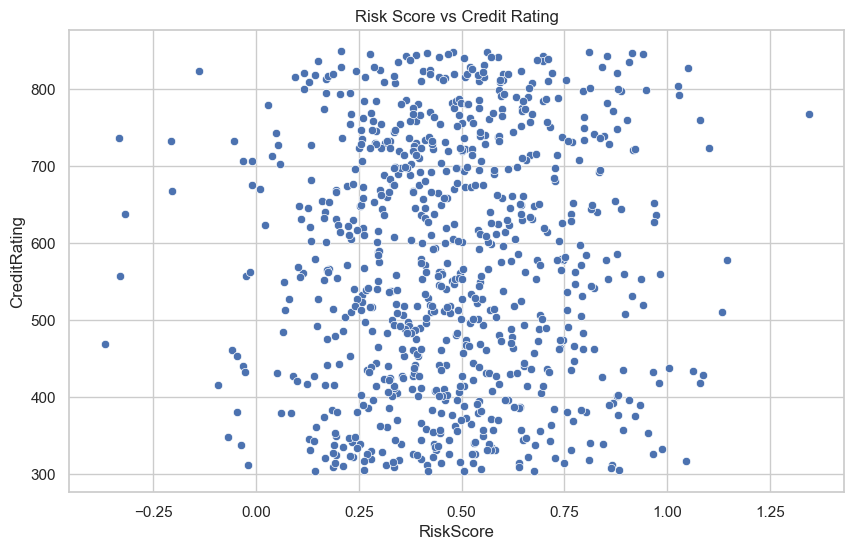

In [41]:
sns.scatterplot(x='RiskScore', y='CreditRating', data=df)
plt.title('Risk Score vs Credit Rating')
plt.show()

**Region wise transaction analysis**

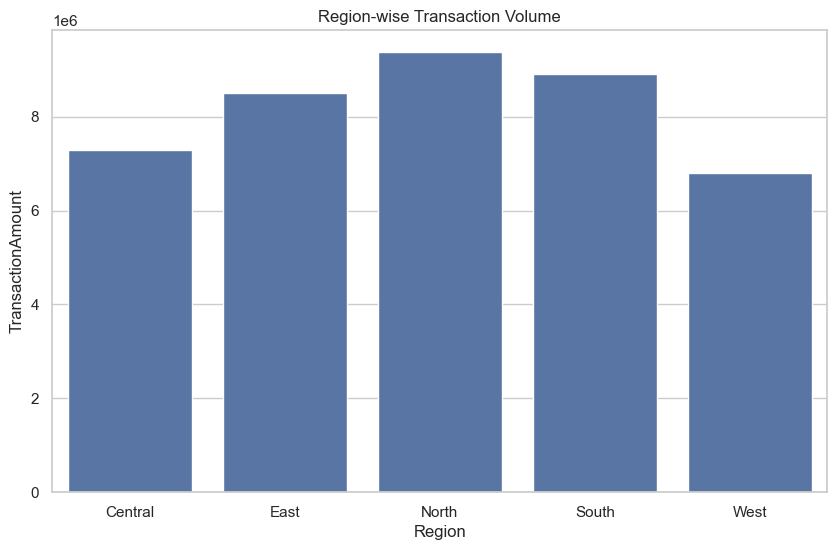

In [42]:
region_data = df.groupby('Region')['TransactionAmount'].sum().reset_index()

sns.barplot(x='Region', y='TransactionAmount', data=region_data)
plt.title('Region-wise Transaction Volume')
plt.show()

**Top Customers**

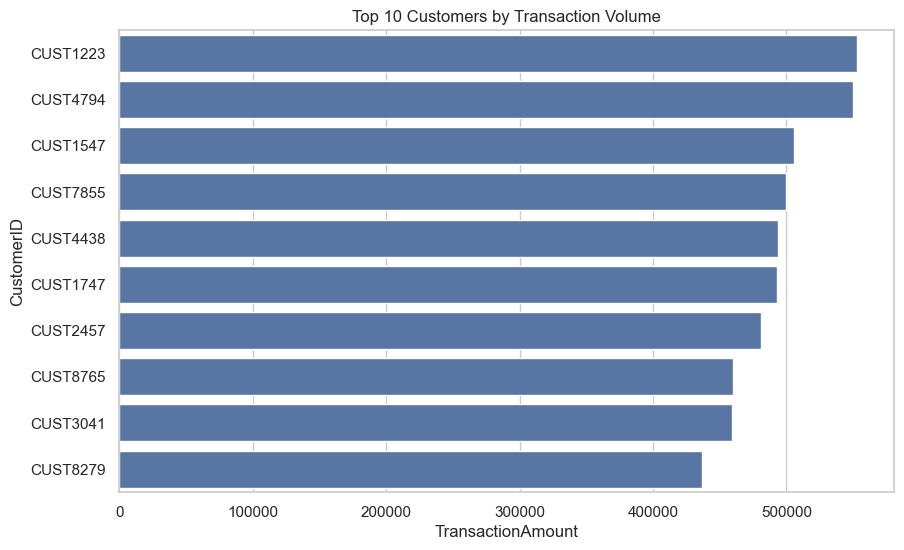

In [43]:
top_customers = df.groupby('CustomerID')['TransactionAmount'].sum().nlargest(10).reset_index()

sns.barplot(x='TransactionAmount', y='CustomerID', data=top_customers)
plt.title('Top 10 Customers by Transaction Volume')
plt.show()

**Outlier Detection**

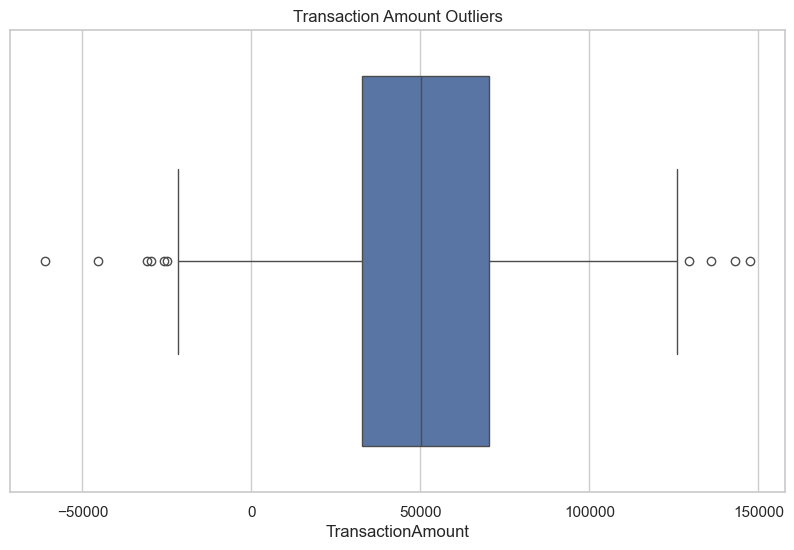

In [44]:
sns.boxplot(x=df['TransactionAmount'])
plt.title('Transaction Amount Outliers')
plt.show()

Correlation heatmap

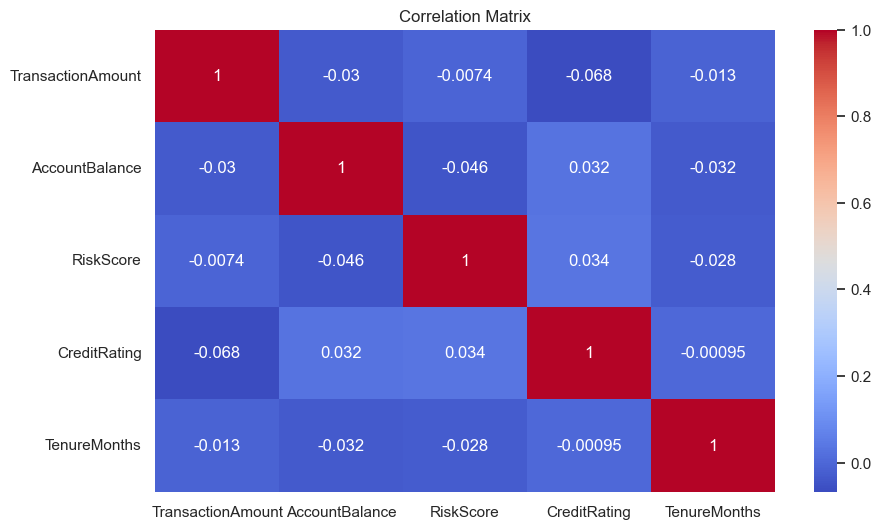

In [45]:
corr = df[['TransactionAmount', 'AccountBalance', 'RiskScore', 'CreditRating', 'TenureMonths']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Volatility Analysis Visualization**

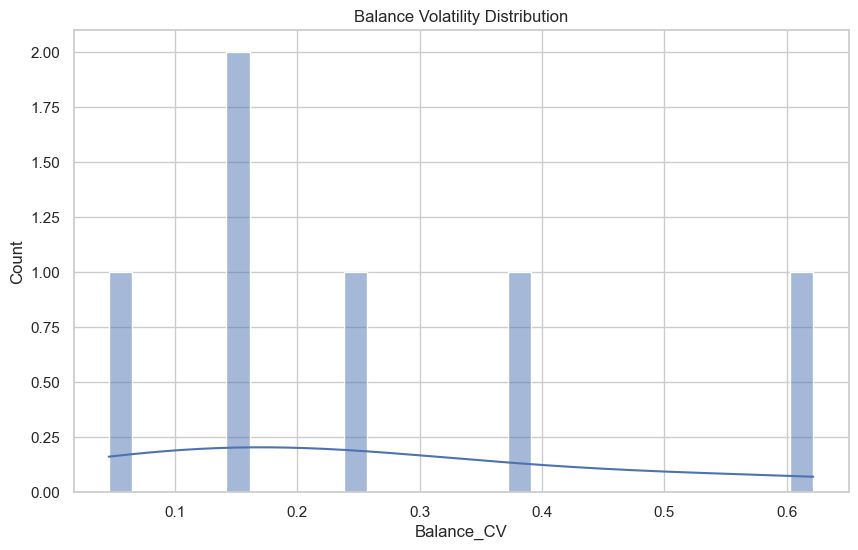

In [47]:
sns.histplot(balance_volatility['Balance_CV'], bins=30, kde=True)
plt.title('Balance Volatility Distribution')
plt.show()

**Hypothesis Testing**
>Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.
>
>Conduct hypothesis testing based on segmentation.

In [48]:
from scipy.stats import ttest_ind

# Extract groups
high_volume_balances = customer_profile[
    customer_profile['Volume_Segment'] == 'High Volume'
]['Avg_Balance']

low_volume_balances = customer_profile[
    customer_profile['Volume_Segment'] == 'Low Volume'
]['Avg_Balance']

# Welch's T-test
t_stat, p_value = ttest_ind(
    high_volume_balances,
    low_volume_balances,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("\nReject Null Hypothesis")
    print("High-volume accounts have statistically higher average balances.")
else:
    print("\nFail to Reject Null Hypothesis")
    print("No statistically significant difference in average balances.")

T-statistic: nan
P-value: nan

Fail to Reject Null Hypothesis
No statistically significant difference in average balances.


C:\Users\mehul\anaconda3\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
